In [24]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df.shape

(7043, 21)

In [3]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [4]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

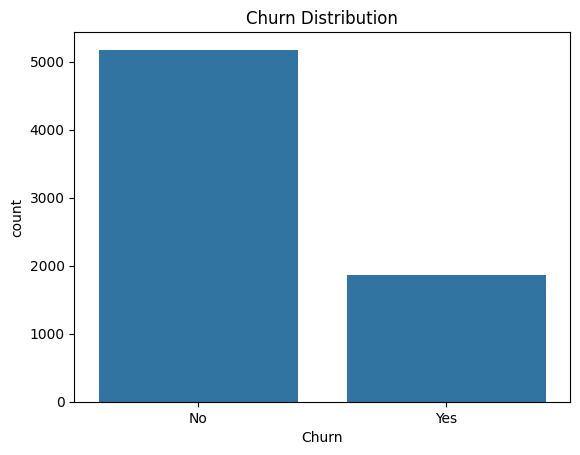

In [7]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

### Churn Distribution
Most customers have not churned. Around 25–30% customers have churned.

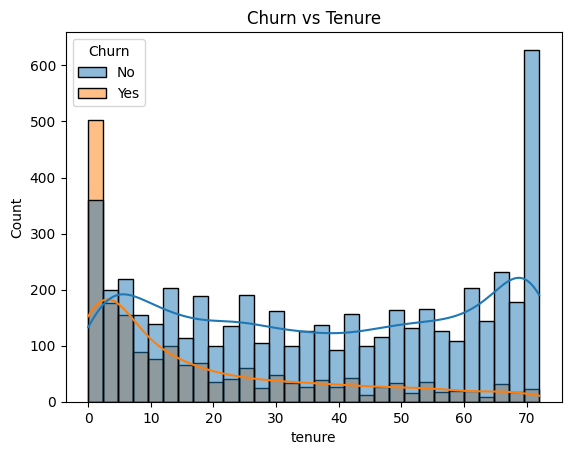

In [8]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Churn vs Tenure")
plt.show()

### Churn vs Tenure
New customers have higher churn rates compared to long-term customers.

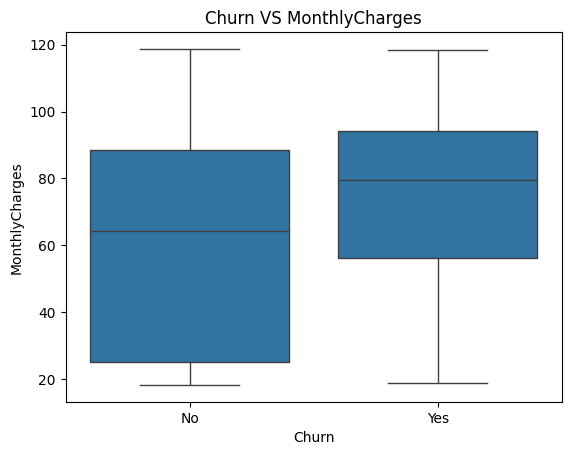

In [9]:
sns.boxplot(x = 'Churn', y ='MonthlyCharges' , data=df)
plt.title("Churn VS MonthlyCharges")
plt.show()

### Churn vs Monthly Charges

Customers with higher monthly charges tend to churn more compared to customers with lower charges.

This indicates that pricing may be a key factor influencing customer churn. High-paying customers might be dissatisfied with the value they receive, leading to higher churn rates.

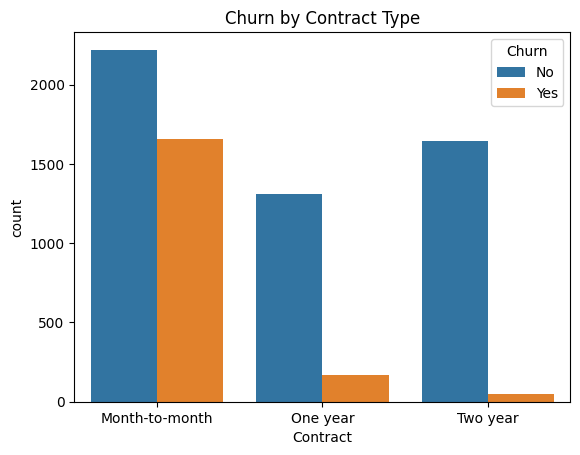

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

### Churn by Contract Type

Customers with month-to-month contracts have the highest churn rate, whereas customers with one-year and two-year contracts show significantly lower churn.

This suggests that customers who are not locked into long-term contracts are more likely to leave the service.

Long-term contracts act as a retention mechanism, reducing the likelihood of churn.

From a business perspective, encouraging customers to shift towards longer-duration contracts can help reduce churn and improve customer retention.

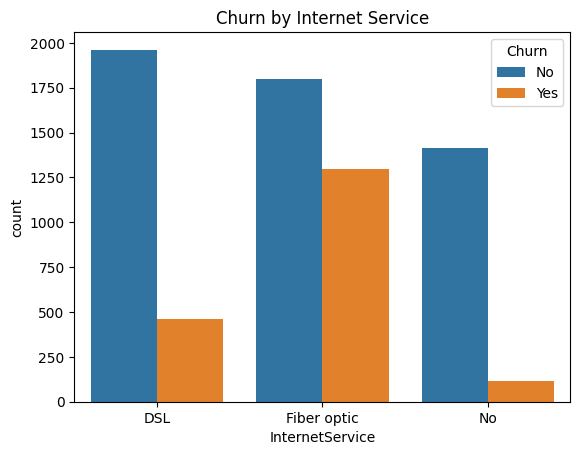

In [11]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

### Churn by Internet Service

Customers using fiber optic internet service show a higher churn rate compared to those using DSL or having no internet service.

This may indicate that fiber optic users are either facing service quality issues or are dissatisfied with pricing, leading to higher churn.

In contrast, DSL users exhibit relatively lower churn, suggesting better customer satisfaction or lower expectations.

From a business perspective, it is important to investigate issues related to fiber optic services, such as pricing, reliability, or customer support, to reduce churn.

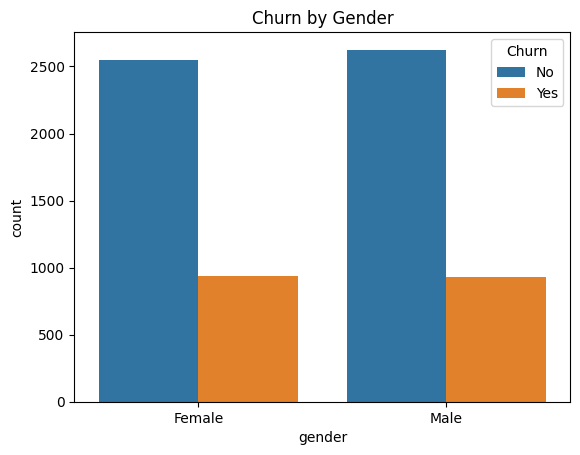

In [12]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Churn by Gender")
plt.show()

### Churn by Gender

The churn rate is almost similar for both male and female customers, indicating that gender does not have a significant impact on customer churn.

This suggests that gender is not a strong predictor of churn and may not play an important role in decision-making for customer retention strategies.

## Model Building

In this step, we prepare the data and train a machine learning model to predict customer churn.

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df = df.drop('customerID', axis=1)

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [26]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## Model Evaluation

The model achieved an accuracy of approximately 79%, indicating good overall performance.

However, the recall for churned customers is relatively low (~47%), which means the model is not able to identify all customers who are likely to churn.

This is important from a business perspective because missing potential churn customers can lead to revenue loss.

Improving recall for churn prediction should be a priority in future improvements.

In [32]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

TotalCharges                      0.193520
tenure                            0.173509
MonthlyCharges                    0.166183
InternetService_Fiber optic       0.044491
PaymentMethod_Electronic check    0.035032
Contract_Two year                 0.032176
gender_Male                       0.028492
PaperlessBilling_Yes              0.024604
OnlineSecurity_Yes                0.024012
TechSupport_Yes                   0.023883
dtype: float64

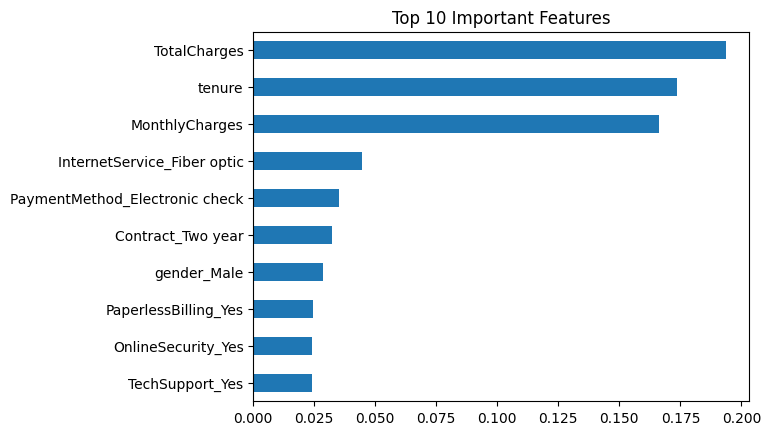

In [33]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

The most important features influencing customer churn include tenure, contract type, and monthly charges.

Customers with shorter tenure and flexible contracts (month-to-month) are more likely to churn, while long-term customers show lower churn probability.

This aligns with the insights observed during exploratory data analysis, validating the model's behavior.

## Feature Importance Analysis

The model identifies TotalCharges, tenure, and MonthlyCharges as the most important features influencing customer churn.

Customers with shorter tenure and higher monthly charges are more likely to churn. Total spending also plays a significant role, indicating customer engagement level.

Additionally, customers using fiber optic internet and electronic payment methods show higher churn tendencies.

Features like gender and paperless billing have relatively low impact, indicating they are not strong predictors of churn.

These findings align with the insights observed during exploratory data analysis, validating the model's behavior.

In [36]:
df.to_csv("../data/cleaned_churn_data.csv", index=False)